In [16]:
# ── Environment & Dependency Setup ─────────────────────────────────────────
# Detects Google Colab vs local runtime, installs missing packages, and sets
# PROJECT_ROOT.  Edit the path constants below if your layout differs.
# Run A1_01_TwoBars_Geometry_to_Graph_v2.ipynb first for the selected layout.

import sys, os, importlib

# ── Runtime detection ──────────────────────────────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Python  : {sys.executable}")

# ── Project root ──────────────────────────────────────────────────────
COLAB_REPO = "/content/GML_Edu"               # git-cloned into Colab
DRIVE_REPO = "/content/drive/MyDrive/GML_Edu" # synced via Google Drive
LOCAL_REPO = "D:/GitHub/GML_Edu"              # ← edit for your local path

# Uncomment to mount Drive before running:
# from google.colab import drive; drive.mount('/content/drive')

if IN_COLAB:
    PROJECT_ROOT = (
        COLAB_REPO if os.path.isdir(COLAB_REPO)
        else DRIVE_REPO if os.path.isdir(DRIVE_REPO)
        else COLAB_REPO
    )
else:
    PROJECT_ROOT = LOCAL_REPO

print(f"Runtime          : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"PROJECT_ROOT     : {PROJECT_ROOT}")
print(f"Repository exists: {os.path.isdir(PROJECT_ROOT)}")               

# ── Install missing packages ───────────────────────────────────────────────
_PACKAGES = [
    ("numpy",      "numpy"),
    ("pandas",     "pandas"),
    ("networkx",   "networkx"),
    ("matplotlib", "matplotlib"),
    ("plotly",     "plotly"),
    ("nbformat",   "nbformat"),
]
_missing_pip = [pip for imp, pip in _PACKAGES if importlib.util.find_spec(imp) is None]
if _missing_pip:
    print(f"Installing: {_missing_pip}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + _missing_pip)
    print("Installation complete.")
else:
    print("All packages present.")

# ── Version report ─────────────────────────────────────────────────────────
_REPORT_PKGS = ["numpy", "pandas", "networkx", "matplotlib", "plotly", "nbformat"]
print("\nPackage versions:")
for _pkg in _REPORT_PKGS:
    try:
        _mod = importlib.import_module(_pkg)
        print(f"  {_pkg:<20}: {getattr(_mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"  {_pkg:<20}: NOT FOUND")

# ── Import verification ────────────────────────────────────────────────────
_errors = []
try:
    import networkx as _nx, pandas as _pd, numpy as _np  # noqa: F401
    import matplotlib as _mpl, plotly as _pl, nbformat as _nbf  # noqa: F401
    print("\nAll library imports   : OK")
except Exception as _e:
    _errors.append(f"core libs: {_e}")

if _errors:
    raise ImportError("Setup failed — fix before continuing:\n" + "\n".join(_errors))

print("Setup complete. Run the cells below in order.")

Python  : d:\AI\envs\genai\python.exe
Runtime          : Local
PROJECT_ROOT     : D:/GitHub/GML_Edu
Repository exists: True
All packages present.

Package versions:
  numpy               : 2.4.4
  pandas              : 3.0.3
  networkx            : 3.6.1
  matplotlib          : 3.10.9
  plotly              : 6.8.0
  nbformat            : 5.10.4

All library imports   : OK
Setup complete. Run the cells below in order.


> **Status: PREPARED — NOT YET EXECUTED**
>
> Use the same `LAYOUT_ID` as A1-01. Each BB layout has its own nodes, edges, and visuals folder.


# MaCAD S.3 — Assignment 1
## A1-02: Graph Visualisation and Export — Two-Bars Residential Studies

Run `A1_01_TwoBars_Geometry_to_Graph.ipynb` first for the selected layout.

Studies: `BB_01`, `BB_02`, `BB_03`.


### Assignment 1 Requirement Checklist (A1-02)

| # | Requirement | Status |
|---|-------------|--------|
| 1 | Load A1 graph from 03_graph_dataset/ | \[ \] Run to confirm |
| 2 | Graph coloured by space_type | \[ \] Run to confirm |
| 3 | Graph coloured by floor_id | \[ \] Run to confirm |
| 4 | Graph coloured by apartment_id | \[ \] Run to confirm |
| 5 | Degree distribution plot | \[ \] Run to confirm |
| 6 | Corridor betweenness analysis printed | \[ \] Run to confirm |
| 7 | Apartment connectivity check printed | \[ \] Run to confirm |
| 8 | All PNG figures saved to 04_visuals/ | \[ \] Run to confirm |
| 9 | Report summary text file saved | \[ \] Run to confirm |


---
## 1. Setup


In [17]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.family"] = "sans-serif"

LAYOUT_ID = "BB_03"
VALID_LAYOUTS = ("BB_01","BB_02","BB_03")
if LAYOUT_ID not in VALID_LAYOUTS:
    raise ValueError(f"Use one of {VALID_LAYOUTS}")

LAYOUT_INFO = {"BB_01":"Compact baseline","BB_02":"Long circulation spine","BB_03":"Wider apartments"}
# PROJECT_ROOT is set by the setup cell above.
ASSIGN_ROOT = os.path.join(PROJECT_ROOT,"assignments","assignment_01_graph_generation")
OUTPUTS_DIR = os.path.join(ASSIGN_ROOT,"03_graph_dataset",LAYOUT_ID)
VISUALS_DIR = os.path.join(ASSIGN_ROOT,"04_visuals",LAYOUT_ID)
os.makedirs(VISUALS_DIR,exist_ok=True)
NODES_CSV = os.path.join(OUTPUTS_DIR,"nodes.csv")
EDGES_CSV = os.path.join(OUTPUTS_DIR,"edges.csv")

print(f"Layout: {LAYOUT_ID} — {LAYOUT_INFO[LAYOUT_ID]}")
for label,path in [("nodes.csv",NODES_CSV),("edges.csv",EDGES_CSV)]:
    status = "OK" if os.path.exists(path) else "MISSING — run A1-01 first"
    print(f"  {label}: [{status}]  {path}")
if not os.path.exists(NODES_CSV) or not os.path.exists(EDGES_CSV):
    raise FileNotFoundError(
        f"Graph dataset for {LAYOUT_ID} not found.\n"
        f"Run A1_01_TwoBars_Geometry_to_Graph_v2.ipynb for {LAYOUT_ID} first.\n"
        f"Expected:\n  {NODES_CSV}\n  {EDGES_CSV}"
    )

Layout: BB_03 — Wider apartments
  nodes.csv: [OK]  D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\04_graph_dataset\BB_03\nodes.csv
  edges.csv: [OK]  D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\04_graph_dataset\BB_03\edges.csv


---
## 2. Load Graph Data


In [18]:
nodes = pd.read_csv(NODES_CSV)
edges = pd.read_csv(EDGES_CSV)
print(f"Nodes loaded: {len(nodes)}")
print(f"Edges loaded: {len(edges)}")
print(f"Columns (nodes): {list(nodes.columns)}")
print(f"Columns (edges): {list(edges.columns)}")
print("\nNodes by space_type:")
print(nodes["space_type"].value_counts().to_string())
if "physical_floor" in nodes.columns:
    print("\nNodes by physical_floor:")
    print(nodes["physical_floor"].value_counts().sort_index().to_string())


Nodes loaded: 141
Edges loaded: 303
Columns (nodes): ['layout_id', 'node_id', 'node_name', 'node_role', 'space_type', 'zone_type', 'apartment_id', 'floor_id', 'physical_floor', 'area', 'volume', 'X', 'Y', 'Z']
Columns (edges): ['layout_id', 'src_id', 'dst_id', 'edge_type', 'contact_axis', 'gap_m', 'shared_span_m', 'physical_floor']

Nodes by space_type:
space_type
Bath        24
Hall        24
Kitchen     24
Living      24
Corridor    18
Bedroom1     8
Bedroom      8
Bedroom2     8
Core         3

Nodes by physical_floor:
physical_floor
0    46
1    47
2    48


In [19]:
# Build NetworkX graph
G = nx.Graph()

for _, row in nodes.iterrows():
    G.add_node(int(row["node_id"]), **row.to_dict())

for _, row in edges.iterrows():
    G.add_edge(int(row["src_id"]), int(row["dst_id"]))

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components  : {nx.number_connected_components(G)}")
print(f"Isolated nodes        : {len(list(nx.isolates(G)))}")
avg_deg = sum(d for _, d in G.degree()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0
print(f"Average degree        : {avg_deg:.2f}")
print(f"Max degree            : {max(d for _, d in G.degree()) if G.number_of_nodes() > 0 else 0}")
print(f"Graph density         : {nx.density(G):.4f}")


NetworkX graph: 141 nodes, 303 edges
Connected components  : 3
Isolated nodes        : 0
Average degree        : 4.30
Max degree            : 8
Graph density         : 0.0307


---
## 3. Colour Palettes and Layouts


In [20]:
# Space-type colour palette (matches Notebook 1)
TYPE_COLORS = {
    "Hall"     : "#FF9800",
    "Bath"     : "#CE93D8",
    "Kitchen"  : "#EF9A9A",
    "Living"   : "#4FC3F7",
    "Bedroom"  : "#B3E5FC",
    "Bedroom1" : "#81D4FA",
    "Bedroom2" : "#4DD0E1",
    "Corridor" : "#81C784",
    "Core"     : "#E57373",
    "unknown"  : "#EEEEEE",
}

# Node size by role
ROLE_SIZES = {"room": 60, "corridor": 160, "core": 120}

# Use XY centroid as 2D layout (plan view — metres)
pos_xy = {}
for n, attrs in G.nodes(data=True):
    x = float(attrs.get("X", 0))
    y = float(attrs.get("Y", 0))
    pos_xy[n] = (x, y)

node_colors = [TYPE_COLORS.get(G.nodes[n].get("space_type", "unknown"), "#EEEEEE")
               for n in G.nodes()]
node_sizes  = [ROLE_SIZES.get(G.nodes[n].get("node_role", "room"), 60)
               for n in G.nodes()]

print("Colour palette and positions ready.")


Colour palette and positions ready.


---
## 4. Figure 1 — Graph Coloured by Space Type

Each node's colour indicates its architectural programme:
Hall (orange) is the apartment entry point and should connect to bath, kitchen, living, and corridor.
Corridors (green) appear as high-degree hubs.


Saved: D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_03\BB_03_02_graph_by_type.png


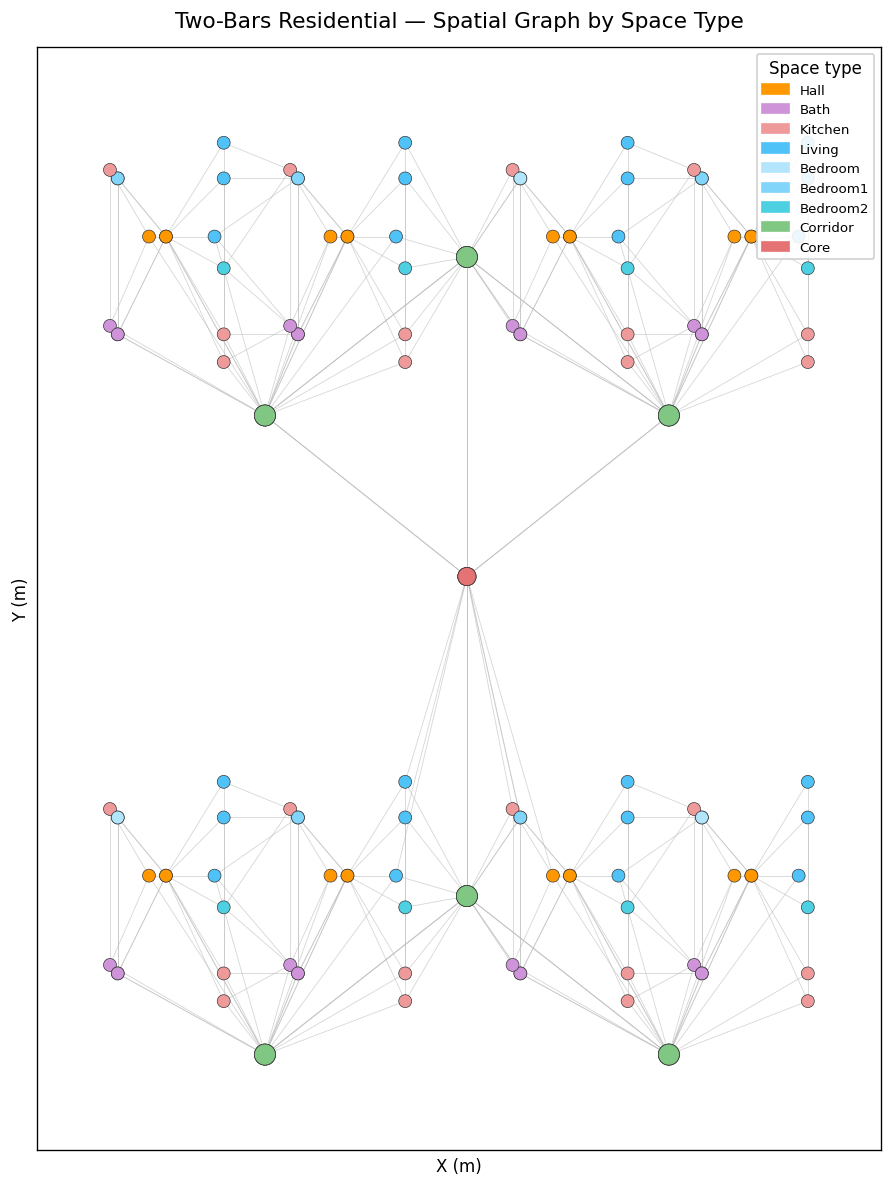

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_edges(G, pos_xy, ax=ax, edge_color="#BBBBBB", width=0.5, alpha=0.6)
nx.draw_networkx_nodes(G, pos_xy, ax=ax,
                       node_color=node_colors,
                       node_size=node_sizes,
                       edgecolors="#333333", linewidths=0.4)

present_types = nodes["space_type"].unique()
legend_patches = [mpatches.Patch(color=c, label=k)
                  for k, c in TYPE_COLORS.items() if k in present_types]
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.9,
          title="Space type")

ax.set_title("Two-Bars Residential — Spatial Graph by Space Type", fontsize=13, pad=12)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
plt.tight_layout()

out_path = os.path.join(VISUALS_DIR, f"{LAYOUT_ID}_02_graph_by_type.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


---
## 5. Figure 2 — Graph Coloured by Floor

Floor-level colouring reveals the vertical repetition of the Double-L plan.
If cross-floor edges appear (corridors connecting adjacent floors via cores), they will
span between colour bands.


Saved: D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_03\BB_03_03_graph_by_physical_floor.png


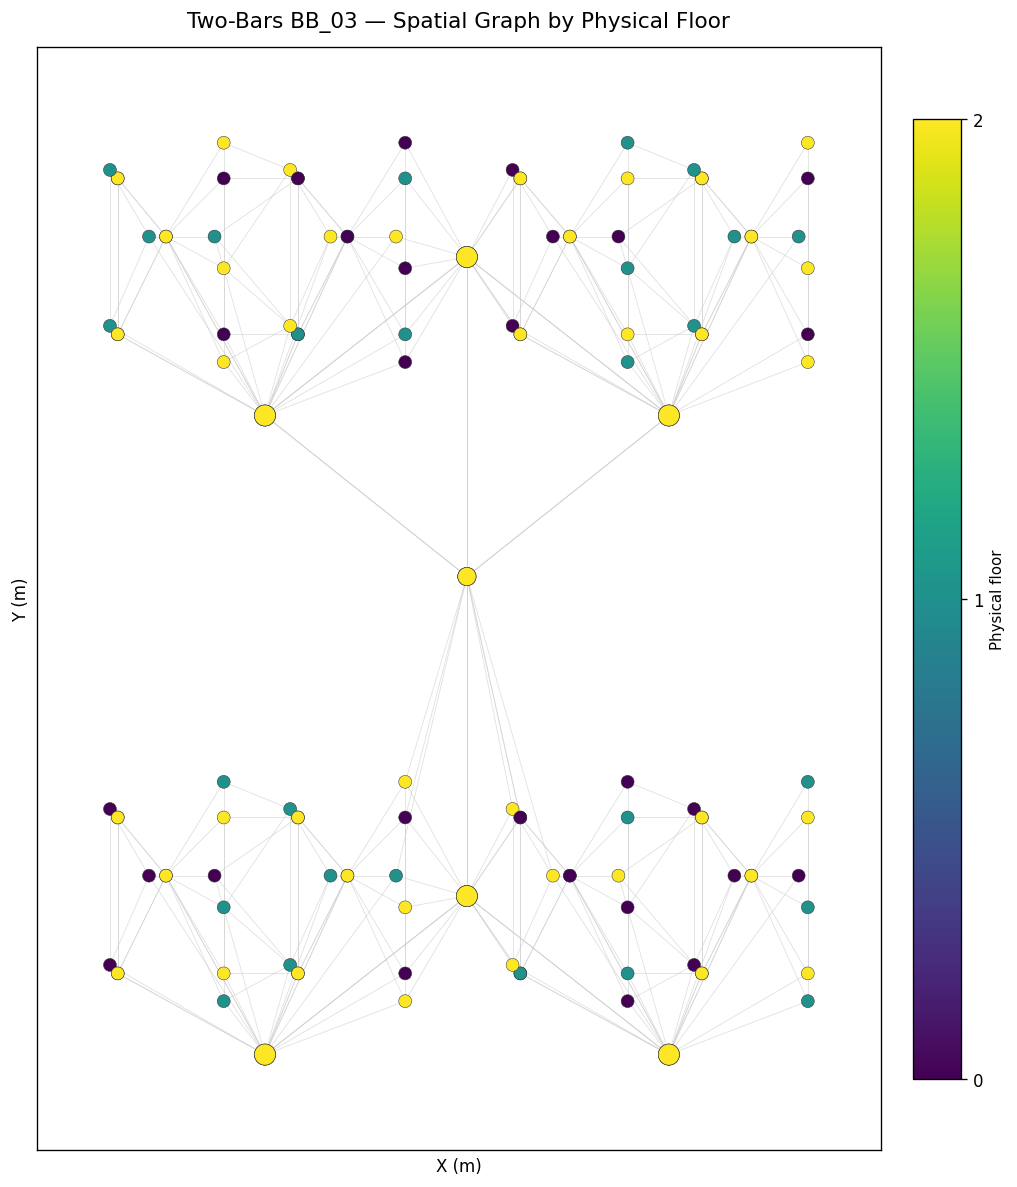

In [22]:
floor_col = "physical_floor" if "physical_floor" in nodes.columns else "floor_id"
floors = sorted(nodes[floor_col].dropna().unique())
floor_cmap = plt.cm.viridis
floor_norm = Normalize(vmin=min(floors) if floors else 0, vmax=max(floors) if len(floors)>1 else 1)

def floor_color(n):
    floor_value = G.nodes[n].get(floor_col)
    return "#EEEEEE" if floor_value is None else floor_cmap(floor_norm(float(floor_value)))

node_colors_f = [floor_color(n) for n in G.nodes()]
fig, ax = plt.subplots(figsize=(14,10))
nx.draw_networkx_edges(G,pos_xy,ax=ax,edge_color="#CCCCCC",width=0.5,alpha=0.6)
nx.draw_networkx_nodes(G,pos_xy,ax=ax,node_color=node_colors_f,node_size=node_sizes,
                       edgecolors="#333333",linewidths=0.3)
sm=plt.cm.ScalarMappable(cmap=floor_cmap,norm=floor_norm); sm.set_array([])
cbar=plt.colorbar(sm,ax=ax,fraction=0.03,pad=0.02)
cbar.set_label("Physical floor",fontsize=9); cbar.set_ticks(floors)
ax.set_title(f"Two-Bars {LAYOUT_ID} — Spatial Graph by Physical Floor",fontsize=13,pad=12)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_aspect("equal")
plt.tight_layout()
out_path=os.path.join(VISUALS_DIR,f"{LAYOUT_ID}_03_graph_by_physical_floor.png")
fig.savefig(out_path,dpi=150,bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


---
## 6. Figure 3 — Apartment Cluster Map

Each apartment receives a distinct hue. Corridor and core nodes remain grey.
This reveals how the 23-apartment-per-floor arrangement spatially clusters and how
each cluster connects to the shared circulation spine.


C:\Users\Eduardo\AppData\Local\Temp\ipykernel_12932\66977615.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  apt_cmap  = cm.get_cmap("tab20", max(n_apts, 1))


Saved: D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_03\BB_03_04_graph_by_apartment.png


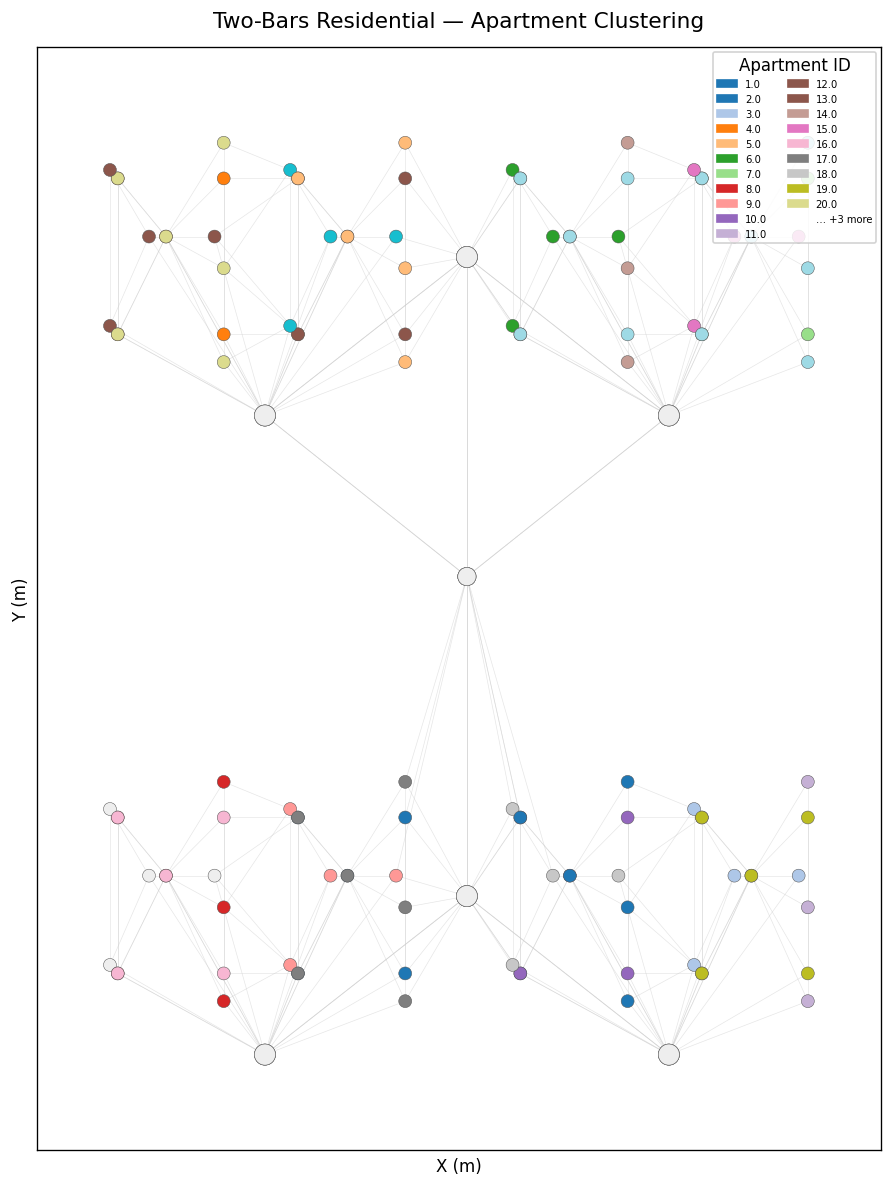

In [23]:
apt_ids = sorted(
    [a for a in nodes["apartment_id"].dropna().unique() if str(a).strip() != ""]
)
n_apts   = len(apt_ids)
apt_cmap  = cm.get_cmap("tab20", max(n_apts, 1))
apt_color = {apt: matplotlib.colors.to_hex(apt_cmap(i))
             for i, apt in enumerate(apt_ids)}

def apt_node_color(n):
    apt = G.nodes[n].get("apartment_id", "")
    if not apt or str(apt).strip() == "":
        return "#CCCCCC"
    return apt_color.get(apt, "#EEEEEE")

node_colors_a = [apt_node_color(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G, pos_xy, ax=ax, edge_color="#CCCCCC", width=0.4, alpha=0.5)
nx.draw_networkx_nodes(G, pos_xy, ax=ax,
                       node_color=node_colors_a,
                       node_size=node_sizes,
                       edgecolors="#555555", linewidths=0.3)

sample_apts = apt_ids[:20]
legend_patches = [mpatches.Patch(color=apt_color[a], label=str(a)) for a in sample_apts]
if n_apts > 20:
    legend_patches.append(mpatches.Patch(color="none", label=f"\u2026 +{n_apts - 20} more"))
ax.legend(handles=legend_patches, loc="upper right", fontsize=6,
          framealpha=0.85, ncol=2, title="Apartment ID")

ax.set_title("Two-Bars Residential — Apartment Clustering", fontsize=13, pad=12)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_aspect("equal")
plt.tight_layout()

out_path = os.path.join(VISUALS_DIR, f"{LAYOUT_ID}_04_graph_by_apartment.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


---
## 7. Figure 4 — Degree Distribution

Degree = number of directly adjacent rooms sharing a wall boundary.

Expected pattern for a residential building with shared-face adjacency:
- Hall nodes: moderate degree (connects to Bath, Kitchen, Living, and corridor)
- Bath / Bedroom nodes: low degree (fewer shared walls)
- Corridor nodes: high degree (shared wall with multiple apartment Halls)


Saved: D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_03\BB_03_05_degree_distribution.png


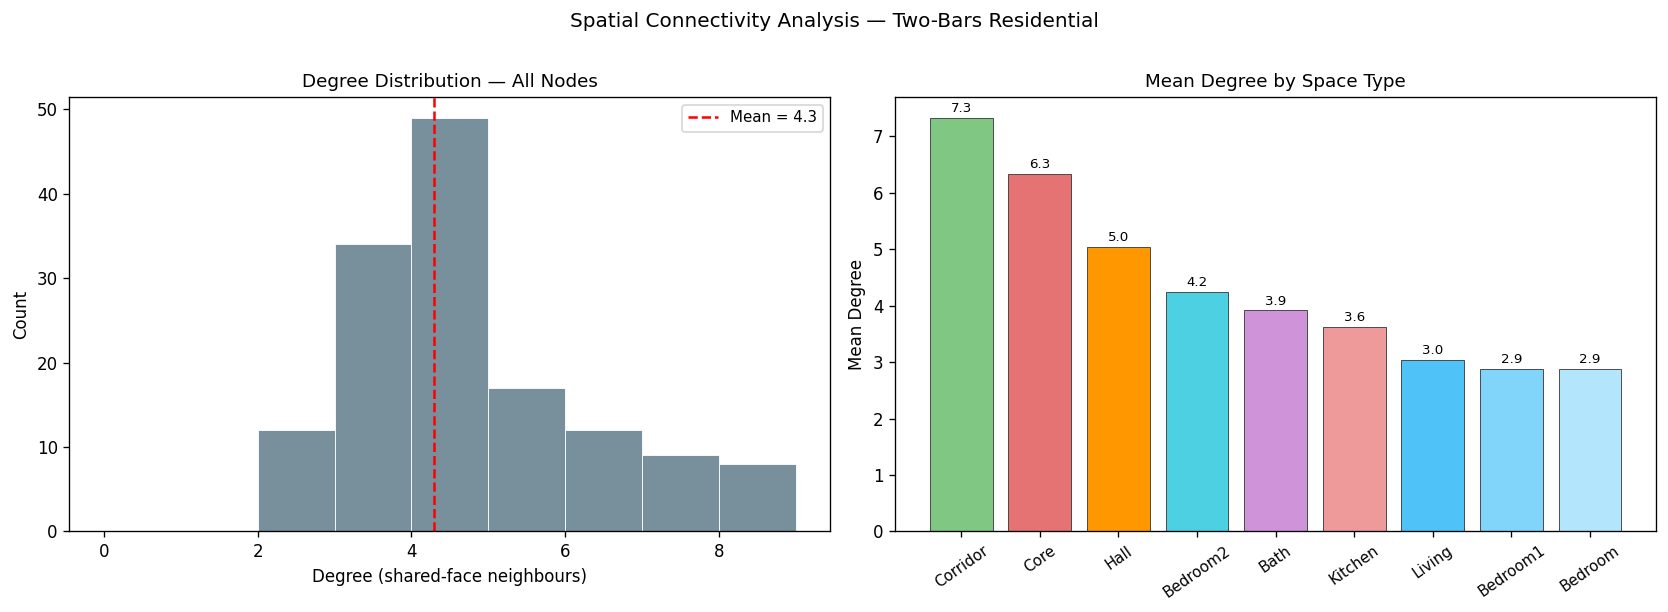

In [24]:
degree_by_type = {}
for n, deg in G.degree():
    st = G.nodes[n].get("space_type", "unknown")
    degree_by_type.setdefault(st, []).append(deg)

all_degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_deg = max(all_degrees) if all_degrees else 1
axes[0].hist(all_degrees, bins=range(0, max_deg + 2), color="#78909C",
             edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Degree (shared-face neighbours)", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].set_title("Degree Distribution — All Nodes", fontsize=11)
mean_deg = np.mean(all_degrees) if all_degrees else 0
axes[0].axvline(mean_deg, color="red", linestyle="--", lw=1.5,
                label=f"Mean = {mean_deg:.1f}")
axes[0].legend(fontsize=9)

type_means   = {st: np.mean(degs) for st, degs in degree_by_type.items() if degs}
sorted_types = sorted(type_means, key=lambda x: type_means[x], reverse=True)
bar_colors   = [TYPE_COLORS.get(st, "#EEEEEE") for st in sorted_types]
bars = axes[1].bar(sorted_types, [type_means[st] for st in sorted_types],
                   color=bar_colors, edgecolor="#333333", linewidth=0.5)
axes[1].set_ylabel("Mean Degree", fontsize=10)
axes[1].set_title("Mean Degree by Space Type", fontsize=11)
axes[1].tick_params(axis="x", rotation=35, labelsize=9)
for bar, st in zip(bars, sorted_types):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{type_means[st]:.1f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Spatial Connectivity Analysis — Two-Bars Residential", fontsize=12, y=1.01)
plt.tight_layout()

out_path = os.path.join(VISUALS_DIR, f"{LAYOUT_ID}_05_degree_distribution.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


---
## 8. Spatial Analysis

Use these cells to generate insights for your written submission.


In [25]:
# Top-degree nodes — which spaces are topologically most connected?
top_n = 10
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:top_n]
print(f"Top {top_n} nodes by degree:")
print(f"{'node':>5}  {'deg':>4}  {'type':12}  {'role':10}  {'apt':20}  {'floor'}")
print("-" * 70)
for n, deg in top_nodes:
    attrs = G.nodes[n]
    print(f"{n:>5}  {deg:>4}  "
          f"{str(attrs.get('space_type','?')):12}  "
          f"{str(attrs.get('node_role','?')):10}  "
          f"{str(attrs.get('apartment_id','')):20}  "
          f"{attrs.get('floor_id','?')}")


Top 10 nodes by degree:
 node   deg  type          role        apt                   floor
----------------------------------------------------------------------
  126     8  Corridor      corridor    nan                   2
  129     8  Corridor      corridor    nan                   0
  130     8  Corridor      corridor    nan                   0
  131     8  Corridor      corridor    nan                   0
  133     8  Corridor      corridor    nan                   1
  134     8  Corridor      corridor    nan                   1
  136     8  Corridor      corridor    nan                   2
  137     8  Corridor      corridor    nan                   2
  120     7  Corridor      corridor    nan                   0
  121     7  Corridor      corridor    nan                   0


In [26]:
# Apartment internal connectivity — are all rooms in an apartment reachable from one another?
apt_col = "apartment_id"
apt_nodes_df = nodes[(nodes[apt_col].notna()) & (nodes[apt_col].astype(str).str.strip() != "")]

print("Apartment internal connectivity:")
fragmented = []
for apt_id, group in apt_nodes_df.groupby(apt_col):
    ids = set(group["node_id"].astype(int))
    sub = G.subgraph(ids)
    comps = nx.number_connected_components(sub)
    iso   = len(list(nx.isolates(sub)))
    if comps != 1 or iso > 0:
        status = f"FRAGMENTED ({comps} components, {iso} isolated)"
        fragmented.append(apt_id)
    else:
        status = "connected"
    print(f"  {str(apt_id):22s}  rooms={len(ids):3d}  [{status}]")

print()
if fragmented:
    print(f"Fragmented apartments: {len(fragmented)}")
    print("  This is expected when rooms share no exact face — see Notebook 1 blocker notes.")
else:
    print("All apartments are internally connected.")


Apartment internal connectivity:
  1.0                     rooms=  5  [connected]
  2.0                     rooms=  6  [connected]
  3.0                     rooms=  4  [connected]
  4.0                     rooms=  5  [connected]
  5.0                     rooms=  6  [connected]
  6.0                     rooms=  4  [connected]
  7.0                     rooms=  5  [connected]
  8.0                     rooms=  6  [connected]
  9.0                     rooms=  4  [connected]
  10.0                    rooms=  5  [connected]
  11.0                    rooms=  6  [connected]
  12.0                    rooms=  4  [connected]
  13.0                    rooms=  5  [connected]
  14.0                    rooms=  6  [connected]
  15.0                    rooms=  4  [connected]
  16.0                    rooms=  5  [connected]
  17.0                    rooms=  6  [connected]
  18.0                    rooms=  4  [connected]
  19.0                    rooms=  5  [connected]
  20.0                    rooms=  6 

In [27]:
# Corridor betweenness centrality — which corridors are most critical?
corr_nodes = [n for n in G.nodes() if G.nodes[n].get("node_role") == "corridor"]

if corr_nodes and G.number_of_edges() > 0:
    between = nx.betweenness_centrality(G, normalized=True)
    print("Corridor betweenness centrality (0=peripheral, 1=most central):")
    for n in sorted(corr_nodes, key=lambda x: between[x], reverse=True):
        attrs = G.nodes[n]
        name  = attrs.get("node_name", str(n))
        fl    = attrs.get("floor_id", "?")
        print(f"  {str(name):28s}  floor={fl}  betweenness={between[n]:.4f}")
elif not corr_nodes:
    print("No corridor nodes found — check node_role attribute in A1_01.")
else:
    print("Graph has no edges — run A1_01 and check adjacency detection.")


Corridor betweenness centrality (0=peripheral, 1=most central):
  BB_03_CORRIDOR_3              floor=1  betweenness=0.0401
  BB_03_CORRIDOR_0              floor=0  betweenness=0.0397
  BB_03_CORRIDOR_6              floor=2  betweenness=0.0389
  BB_03_CORRIDOR_16             floor=2  betweenness=0.0358
  BB_03_CORRIDOR_17             floor=2  betweenness=0.0354
  BB_03_CORRIDOR_14             floor=1  betweenness=0.0305
  BB_03_CORRIDOR_10             floor=0  betweenness=0.0299
  BB_03_CORRIDOR_13             floor=1  betweenness=0.0284
  BB_03_CORRIDOR_11             floor=0  betweenness=0.0278
  BB_03_CORRIDOR_4              floor=1  betweenness=0.0265
  BB_03_CORRIDOR_5              floor=1  betweenness=0.0262
  BB_03_CORRIDOR_7              floor=2  betweenness=0.0227
  BB_03_CORRIDOR_1              floor=0  betweenness=0.0199
  BB_03_CORRIDOR_9              floor=0  betweenness=0.0193
  BB_03_CORRIDOR_8              floor=2  betweenness=0.0191
  BB_03_CORRIDOR_2              floo

---
## 9. Assignment 1 Report Summary


In [28]:
n_rooms = len(nodes[nodes["node_role"]=="room"]) if "node_role" in nodes.columns else len(nodes)
n_corr = len(nodes[nodes["node_role"]=="corridor"]) if "node_role" in nodes.columns else 0
n_core = len(nodes[nodes["node_role"]=="core"]) if "node_role" in nodes.columns else 0
floor_col = "physical_floor" if "physical_floor" in nodes.columns else "floor_id"
n_floors = nodes[floor_col].nunique()
report = f"""
MaCAD S.3 — Assignment 1
Two-Bars {LAYOUT_ID}: {LAYOUT_INFO[LAYOUT_ID]}

Nodes: {G.number_of_nodes()} | Rooms: {n_rooms} | Corridors: {n_corr} | Cores: {n_core}
Edges: {G.number_of_edges()}
Physical floors: {n_floors}
Components: {nx.number_connected_components(G)}
Isolated nodes: {len(list(nx.isolates(G)))}

Method: Graph.ByTopology using exact shared-face adjacency.
Limitation: wall thickness can prevent intended adjacencies.
"""
print(report)
report_path=os.path.join(VISUALS_DIR,f"{LAYOUT_ID}_assignment1_report_summary.txt")
with open(report_path,"w",encoding="utf-8") as f:
    f.write(report)
print(f"Report saved: {report_path}")



MaCAD S.3 — Assignment 1
Two-Bars BB_03: Wider apartments

Nodes: 141 | Rooms: 120 | Corridors: 18 | Cores: 3
Edges: 303
Physical floors: 3
Components: 3
Isolated nodes: 0

Method: Graph.ByTopology using exact shared-face adjacency.
Limitation: wall thickness can prevent intended adjacencies.

Report saved: D:/GitHub/GML_Edu\assignments\assignment_01_graph_generation\05_visuals\BB_03\BB_03_assignment1_report_summary.txt


---
## Node / Edge Mapping Explanation

Include this interpretation in your submission:

| Spatial element | Graph element | Attribute encoded |
|-----------------|--------------|------------------|
| Room (Hall, Bath, Kitchen, Living, Bedroom) | Node | space_type, zone_type, apartment_id, floor_id, area |
| Corridor segment | Node (high-degree hub) | node_role = corridor, floor_id |
| Core (stair / lift) | Node | node_role = core |
| Shared wall face between two rooms | Edge | edge_type = adjacency |

**Why this graph?** The shared-face adjacency graph encodes the topological skeleton of
the building — which spaces touch which. With 23 apartments per floor and a central
corridor spine, the graph reveals the Double-L's characteristic "double-loaded corridor"
structure: each corridor node connects to the Halls of all apartments on that floor.

---
## Final Submission Checklist

- [ ] All PNG figures saved to `04_visuals/`
- [ ] `assignment1_report_summary.txt` saved
- [ ] Degree distribution plot shows non-trivial spread
- [ ] Betweenness centrality printed for corridors
- [ ] Apartment connectivity check shows results
- [ ] Copy `03_graph_dataset/nodes.csv` + `edges.csv` to `../assignment_02_graph_analysis/01_notebook_work/` before running Assignment 2
